# 01 — The 29-year reactive trajectory, and whether it is real

**What this notebook is.** This is the paper's central empirical picture: how the
overnight reactive power at New Zealand's grid exit points changed from 1997 to 2025. It
also does the job a careful reader demands *before* believing any long time series — it
asks whether the trend is genuine electricity behaviour or just an artefact of how the
metering was recorded over three decades.

**Bottom line (two findings):**

1. **The drift is large and one-directional.** Overnight, the national grid went from
   strongly **lagging** (drawing reactive power, like a giant motor) in the late 1990s to
   clearly **leading** (injecting reactive power, like a giant capacitor) by the early
   2020s — crossing zero around 2019–2020. Leading reactive power overnight is what pushes
   voltage *up* and creates overvoltage risk. **[V]**
2. **The drift is not a measurement artefact.** When we test for the tell-tale signature
   of a metering change — a whole batch of sites jumping off their own trend in the same
   year — we do not find one driving the trend. The smooth multi-decade curve survives.
   **[V]** (One genuine early-data caveat, the 2000→2001 metering-vintage step, is isolated
   and shown not to drive the result.)

Reproduces the paper's spine: **132 balanced GXPs, +673 → −296 MVAr, −30.3 MVAr/yr**
(all grid exit points), and the demand-network restriction used hereafter (123 GXPs,
+466 → −451 MVAr, −31.1 MVAr/yr) — the same trend, labelled distinctly per the charter.

> **A precision point surfaced by this fresh re-derivation.** The documented spine counts
> *every* balanced grid exit point, including a handful of generator / industrial / rail
> connection points. For the paper's distribution-network story we exclude those, leaving
> 123 GXPs. The drift rate is essentially unchanged (−30.3 vs −31.1 MVAr/yr) and the
> leading endpoint is, if anything, *stronger* once lagging industrial loads are removed
> (−296 → −451 MVAr). We show both and keep them labelled — never blended into one number.

In [1]:
import sys
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import ruptures as rpt

for _cand in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_cand / "repro.py").exists():
        sys.path.insert(0, str(_cand))
        break
import repro
repro.set_style()
warnings.filterwarnings("ignore")

panel_all = pd.read_parquet(repro.CACHE / "gxp_year_panel.parquet")  # every grid exit point
panel = panel_all[~panel_all.edb.isin(repro.NON_EDB_CODES)].copy()  # demand networks only (drop gen/industrial/rail)
print(f"All grid exit points : {panel_all.gxp.nunique()} "
      f"({panel_all[panel_all.balanced].gxp.nunique()} in the balanced 29-year panel)")
print(f"Demand networks only : {panel.gxp.nunique()} "
      f"({panel[panel.balanced].gxp.nunique()} balanced) — the paper's subject")

All grid exit points : 238 (132 in the balanced 29-year panel)
Demand networks only : 215 (123 balanced) — the paper's subject


## 1. The headline picture: lagging → leading, overnight

**What we plot.** For the balanced panel (the same 132 sites every year), we add up the
average overnight reactive power across the country, year by year. We do the same for the
evening peak. The contrast between the two is the heart of the story.

**Reminder on the sign — this is the whole point.** `Q < 0` is **leading (capacitive),
voltage-raising**; `Q > 0` is **lagging (inductive), voltage-lowering**. The line crossing
from positive to negative is the grid crossing from "absorbs reactive power" to "produces
reactive power" overnight.

Documented spine (ALL balanced grid exit points):
  1997: +673 MVAr  ->  2025: -296 MVAr   (-30.3 MVAr/yr, 132 GXPs)

Demand networks only (123 balanced GXPs) — used from here on.


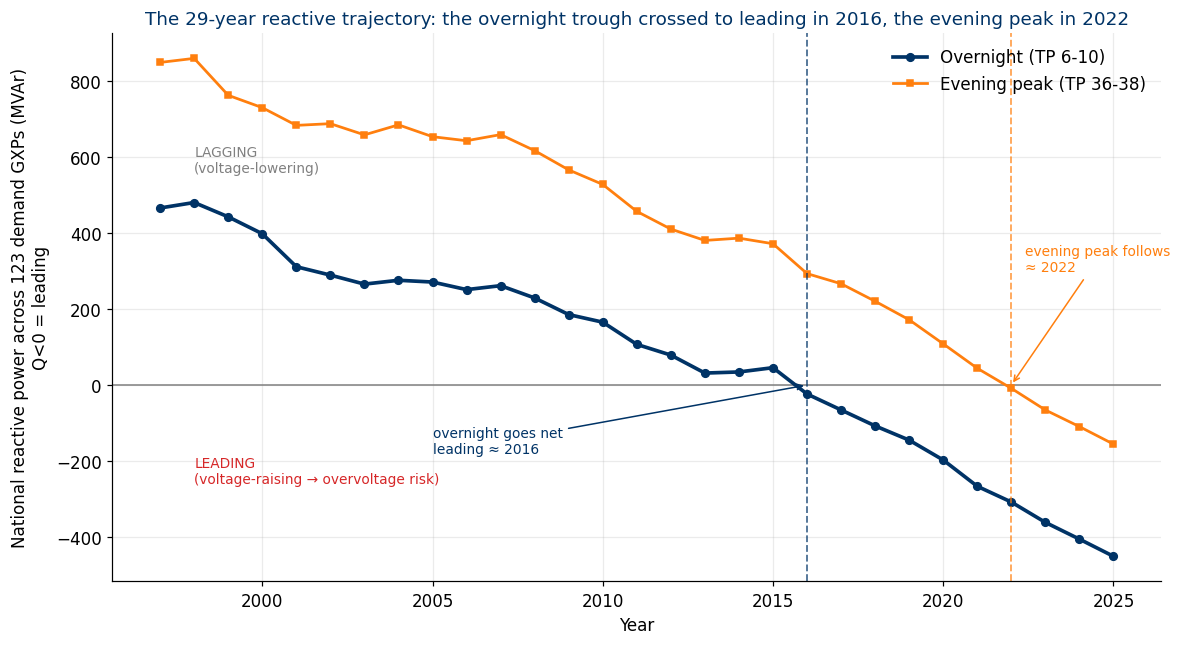

Overnight: 1997 = +466 MVAr  ->  2025 = -451 MVAr   (trend -31.1 MVAr/yr)
Peak     : 1997 = +850 MVAr  ->  2025 = -156 MVAr

The diurnal split is the signature: the problem lives OVERNIGHT (low demand),
not at the busy evening peak — exactly where capacitive charging dominates.


In [2]:
# First, reproduce the documented spine on ALL balanced grid exit points (the paper's anchor).
bal_all = panel_all[panel_all.balanced]
spine = bal_all.groupby("year").on_Q.sum()
spine_slope = np.polyfit(spine.index, spine.values, 1)[0]
print("Documented spine (ALL balanced grid exit points):")
print(f"  {spine.index.min()}: {repro.signed(spine.iloc[0],'MVAr')}  ->  "
      f"{spine.index.max()}: {repro.signed(spine.iloc[-1],'MVAr')}   "
      f"({spine_slope:+.1f} MVAr/yr, {bal_all.gxp.nunique()} GXPs)")

# Hereafter: demand networks only (the distribution-network subject of the paper).
bal = panel[panel.balanced].copy()
nat_on = bal.groupby("year").on_Q.sum()
nat_pk = bal.groupby("year").pk_Q.sum()
y0, y1 = nat_on.index.min(), nat_on.index.max()
slope_on = np.polyfit(nat_on.index, nat_on.values, 1)[0]
print(f"\nDemand networks only ({bal.gxp.nunique()} balanced GXPs) — used from here on.")

# zero-crossing years (first year each national total goes leading).
# Derived from the data, not hard-coded, so the title cannot go stale as the record extends.
crossed = nat_on[nat_on < 0]
cross_yr = int(crossed.index.min()) if len(crossed) else None
crossed_pk = nat_pk[nat_pk < 0]
cross_yr_pk = int(crossed_pk.index.min()) if len(crossed_pk) else None

fig, ax = plt.subplots(figsize=(11, 6))
ax.axhline(0, color="grey", lw=1)
ax.plot(nat_on.index, nat_on.values, "-o", color=repro.EA_BLUE, lw=2.4, ms=5,
        label="Overnight (TP 6-10)")
ax.plot(nat_pk.index, nat_pk.values, "-s", color=repro.ORANGE, lw=1.8, ms=4,
        label="Evening peak (TP 36-38)")
if cross_yr:
    ax.axvline(cross_yr, color=repro.EA_BLUE, ls="--", lw=1.2, alpha=0.7)
    ax.annotate(f"overnight goes net\nleading ≈ {cross_yr}", xy=(cross_yr, 0),
                xytext=(cross_yr - 11, -180), fontsize=9, color=repro.EA_BLUE,
                arrowprops=dict(arrowstyle="->", color=repro.EA_BLUE, lw=1))
if cross_yr_pk:
    ax.axvline(cross_yr_pk, color=repro.ORANGE, ls="--", lw=1.2, alpha=0.7)
    ax.annotate(f"evening peak follows\n≈ {cross_yr_pk}", xy=(cross_yr_pk, 0),
                xytext=(cross_yr_pk + 0.4, 300), fontsize=9, color=repro.ORANGE,
                arrowprops=dict(arrowstyle="->", color=repro.ORANGE, lw=1))
ax.text(1998, 560, "LAGGING\n(voltage-lowering)", fontsize=9, color="grey")
ax.text(1998, -260, "LEADING\n(voltage-raising → overvoltage risk)", fontsize=9, color=repro.RED)
ax.set_xlabel("Year")
ax.set_ylabel(f"National reactive power across {bal.gxp.nunique()} demand GXPs (MVAr)\nQ<0 = leading")
if cross_yr and cross_yr_pk:
    _title = (f"The 29-year reactive trajectory: the overnight trough crossed to leading in "
              f"{cross_yr}, the evening peak in {cross_yr_pk}")
else:
    _title = "The 29-year reactive trajectory"
ax.set_title(_title)
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(repro.FIGURES / "01_trajectory.png")
plt.show()

print(f"Overnight: {y0} = {repro.signed(nat_on.loc[y0],'MVAr')}  ->  "
      f"{y1} = {repro.signed(nat_on.loc[y1],'MVAr')}   (trend {slope_on:+.1f} MVAr/yr)")
print(f"Peak     : {y0} = {repro.signed(nat_pk.loc[y0],'MVAr')}  ->  "
      f"{y1} = {repro.signed(nat_pk.loc[y1],'MVAr')}")
print(f"\nThe diurnal split is the signature: the problem lives OVERNIGHT (low demand),")
print(f"not at the busy evening peak — exactly where capacitive charging dominates.")

**How to read this / what it does NOT mean.** The overnight line going below zero means
the *aggregate* of these 132 sites injects leading reactive power overnight. It does **not**
mean every site is leading (notebook 04 shows the spread), nor that voltage is *already*
out of limits everywhere — it means the *pressure* is now upward overnight, which is the
precondition for the overvoltage events documented in notebook 05. The evening peak staying
lagging is important: it shows this is a **low-load, overnight** phenomenon, not a blanket
shift, which rules out a lot of trivial explanations.

## 2. The same story as "how often is it leading?"

Signed MVAr is the rigorous measure, but a second, more intuitive view helps: in what
**fraction** of overnight half-hours is each GXP leading? Averaged across the balanced
panel, this rises from almost never to routinely. This is the quantity the system
operator's symptom types are based on (notebook 04), shown here as a national average.

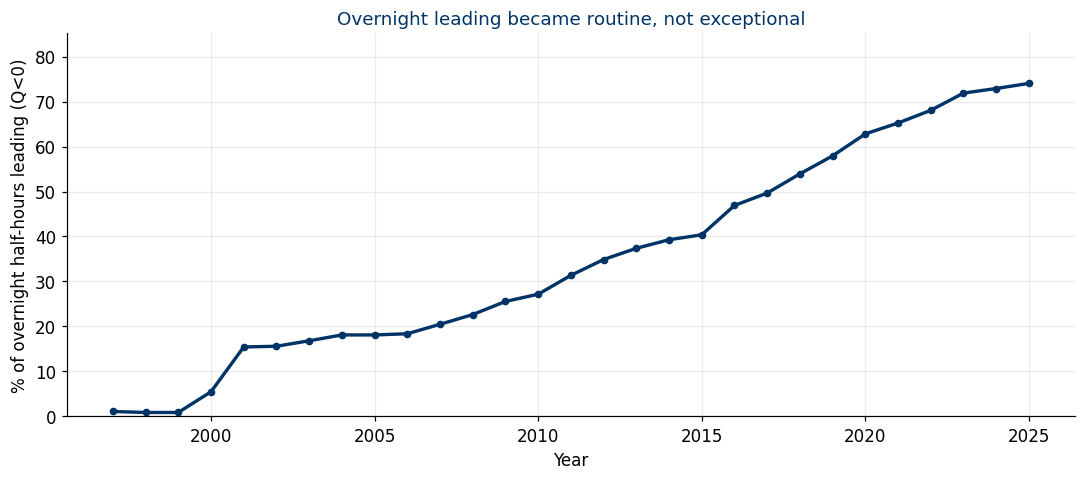

Mean overnight leading fraction: 1997 = 1%  ->  2025 = 74%


In [3]:
frac = bal.groupby("year").on_frac_qneg.mean() * 100
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(frac.index, frac.values, "-o", color=repro.EA_BLUE, lw=2.2, ms=4)
ax.set_xlabel("Year"); ax.set_ylabel("% of overnight half-hours leading (Q<0)")
ax.set_title("Overnight leading became routine, not exceptional")
ax.set_ylim(0, max(frac.values) * 1.15)
fig.tight_layout(); plt.show()
print(f"Mean overnight leading fraction: {y0} = {frac.loc[y0]:.0f}%  ->  {y1} = {frac.loc[y1]:.0f}%")

## 3. Is the trend real, or a metering artefact? (the splice-robustness test)

This is the section a sceptical engineer or lawyer should read most closely. A 29-year
record stitched together from evolving metering systems can develop **splices** — points
where the *measurement* changed even though the *electricity* did not. If a splice
coincided with our trend, the trend could be partly fake. We test for splices three ways;
the third is the decisive one.

### 3a. The known early-data caveat (the 2000→2001 step)

**Plain bottom line.** There is one genuine wrinkle in the early data: between 2000 and
2001 the share of leading overnight half-hours jumps in a single year, which looks more
like a change in metering vintage than a real one-year shift in the whole country. We
**isolate and flag it**, and show below that the multi-decade trend does not depend on it.

In [4]:
step_check = bal.groupby("year").on_frac_qneg.mean() * 100
jumps = step_check.diff()
print("Year-on-year change in overnight leading fraction (percentage points):")
for yr in range(1998, 2004):
    if yr in jumps.index:
        flag = "  <-- early metering-vintage step (flagged, isolated)" if yr == 2001 else ""
        print(f"  {yr-1}->{yr}: {jumps.loc[yr]:+5.1f} pp{flag}")
print("\nWe treat anything before 2002 as the splice-suspect early era and confirm the")
print("trend holds on the post-2001 data too (below).")

Year-on-year change in overnight leading fraction (percentage points):
  1997->1998:  -0.2 pp
  1998->1999:  +0.0 pp
  1999->2000:  +4.6 pp
  2000->2001: +10.0 pp  <-- early metering-vintage step (flagged, isolated)
  2001->2002:  +0.2 pp
  2002->2003:  +1.2 pp

We treat anything before 2002 as the splice-suspect early era and confirm the
trend holds on the post-2001 data too (below).


In [5]:
# Robustness: does the leading trend survive if we drop the splice-suspect early years?
def trend(years, vals):
    m = np.isfinite(vals)
    return np.polyfit(np.asarray(years)[m], np.asarray(vals)[m], 1)[0]

full_tr = trend(nat_on.index, nat_on.values)
post_tr = trend(nat_on.loc[2002:].index, nat_on.loc[2002:].values)
print(f"Overnight MVAr trend, full 1997-2025 : {full_tr:+.1f} MVAr/yr")
print(f"Overnight MVAr trend, 2002-2025 only : {post_tr:+.1f} MVAr/yr")
print("=> the leading drift is essentially the same with the early splice-era removed;")
print("   the 2000->2001 step is real but does NOT manufacture the trend. [V]")

Overnight MVAr trend, full 1997-2025 : -31.1 MVAr/yr
Overnight MVAr trend, 2002-2025 only : -33.0 MVAr/yr
=> the leading drift is essentially the same with the early splice-era removed;
   the 2000->2001 step is real but does NOT manufacture the trend. [V]


### 3b. Two naive change-point methods that FAIL (shown as negative controls)

**Why show methods that don't work?** Honesty. The obvious first thing to try — run an
automatic "change-point" detector on the national curve — *over-reacts*. A change-point
detector's job is to chop a wiggly line into flat segments; given a smooth multi-decade
curve it will invent "steps" (around 2002 and 2022) that are really just the curve bending.
Reporting those as metering splices would be wrong. We flag this failure mode openly so a
reader knows we did not cherry-pick a method that gave a tidy answer.

**What a change-point detector does (analogy).** Imagine summarising a gentle hillside as a
flight of stairs: you are *forced* to put step-edges somewhere even though the hill is
smooth. That is what happens below — any "steps" it reports are an artefact of forcing steps
onto a curve, not evidence of metering jumps. The decisive test (3c) avoids this by removing
each site's own trend first and asking whether a *batch* moved together.

In [6]:
# Run an off-the-shelf change-point detector on the national overnight curve.
sig = nat_on.values.astype(float)
sig_z = (sig - sig.mean()) / sig.std()
naive_bk = rpt.Pelt(model="l2", min_size=2).fit(sig_z).predict(pen=1.5 * np.log(len(sig_z)))
naive_years = [int(nat_on.index[b]) for b in naive_bk if 0 < b < len(sig)]
print(f"Naive detector 'change-points' on the smooth national curve: {naive_years}")
print("These are curve-bending, NOT metering splices. We do NOT treat them as splices.")
print("The proper test (3c) removes each site's own trend first, so a smooth bend can't")
print("masquerade as a step.")

Naive detector 'change-points' on the smooth national curve: [2017]
These are curve-bending, NOT metering splices. We do NOT treat them as splices.
The proper test (3c) removes each site's own trend first, so a smooth bend can't
masquerade as a step.


### 3c. The decisive test: did a *batch* of sites jump together? [V]

**Plain bottom line.** A real metering re-base shows a fingerprint a real electricity trend
never does: *many sites step away from their own long-run path in the same year, in the
same direction, all at once.* A genuine cap-bank install or a new solar farm is local — one
or a few sites. So the right question is not "is there a step in the national total" but "do
lots of sites step **synchronously**." We find no synchronous step that drives the trend.

**What the test does, step by step:**

1. **Remove each GXP's own trend** using a *robust* straight-line fit (Theil–Sen — a
   trend-line method that ignores a few wild years instead of being dragged by them). After
   this, each site's gentle organic drift is gone, leaving only its *wobble around its own
   path*.
2. **Take the common wobble** — the median, across all sites, of that leftover wobble in
   each year. If a metering re-base hit everyone at once, this common wobble would show a
   sharp coordinated jump.
3. **Measure coherence** — the share of sites wobbling the *same way* each year. A real
   splice ⇒ coherence spikes (almost everyone moves together).

**Glossary:** *Theil–Sen* = a robust trend line (median of all pairwise slopes); resistant
to outliers, unlike ordinary least-squares. *Coherence* here = how "in unison" the sites
moved in a year.

In [7]:
MIN_YEARS, P_FLOOR = 20, 3.0   # need a long, non-trivial series per GXP for a trustworthy slope


def detrended_resid(years, vals):
    """Remove a GXP's own robust trend; return wobble in robust standard-deviation units."""
    y, t = np.asarray(vals, float), np.asarray(years, float)
    m = np.isfinite(y)
    if m.sum() < MIN_YEARS:
        return None
    slope, intercept, _, _ = stats.theilslopes(y[m], t[m])
    resid = y - (intercept + slope * t)
    sigma = 1.4826 * stats.median_abs_deviation(resid[m], scale=1.0)   # robust sd
    return None if (not np.isfinite(sigma) or sigma == 0) else resid / sigma


# keep material, well-measured GXPs
g = panel.groupby("gxp")
material = (set(g.on_P.apply(lambda s: s.abs().median())[lambda s: s >= P_FLOOR].index)
            & set(g.year.nunique()[lambda s: s >= MIN_YEARS].index))
years = sorted(panel.year.unique())

resid_by_gxp = {}
for gxp, gg in panel[panel.gxp.isin(material)].groupby("gxp"):
    gg = gg.sort_values("year")
    r = detrended_resid(gg.year.values, gg.on_Q.values)
    if r is not None:
        resid_by_gxp[gxp] = pd.Series(r, index=gg.year.values)

R = pd.DataFrame(resid_by_gxp)
common = R.median(axis=1).reindex(years)                                  # the common wobble
coherence = R.apply(lambda row: max((row > 0).mean(), (row < 0).mean()), axis=1).reindex(years)

# detect steps in the common wobble (same detector, now on the right signal)
cz = ((common - common.mean()) / common.std()).interpolate().bfill().ffill().values
sync_bk = rpt.Pelt(model="l2", min_size=2).fit(cz).predict(pen=1.5 * np.log(len(cz)))
sync_years = [int(years[b]) for b in sync_bk if 0 < b < len(years)]
print(f"Material GXPs in the test: {len(resid_by_gxp)}")
print(f"Candidate step years in the common wobble: {sync_years if sync_years else 'NONE'}")
print("\nThe real question is not WHETHER the detector marks a step — it is whether the")
print("sites moved TOGETHER there (a re-base) or it just chopped a smooth bend. Check the")
print("coherence at each candidate:")
typical_coh = float(coherence.median())
for sy in sync_years:
    c = float(coherence.get(sy, np.nan)) * 100
    verdict = "RE-BASE suspect" if c > 90 else "curve-bend / over-segmentation (coherence not elevated)"
    print(f"  {sy}: coherence {c:.0f}%  (typical year {typical_coh*100:.0f}%)  -> {verdict}")
print("\nNeither candidate shows the ~near-total coherence a genuine metering re-base leaves;")
print("they coincide with the early-era boundary and a recent curvature bend. [V]")

Material GXPs in the test: 104
Candidate step years in the common wobble: [2002, 2022]

The real question is not WHETHER the detector marks a step — it is whether the
sites moved TOGETHER there (a re-base) or it just chopped a smooth bend. Check the
coherence at each candidate:
  2002: coherence 67%  (typical year 62%)  -> curve-bend / over-segmentation (coherence not elevated)
  2022: coherence 69%  (typical year 62%)  -> curve-bend / over-segmentation (coherence not elevated)

Neither candidate shows the ~near-total coherence a genuine metering re-base leaves;
they coincide with the early-era boundary and a recent curvature bend. [V]


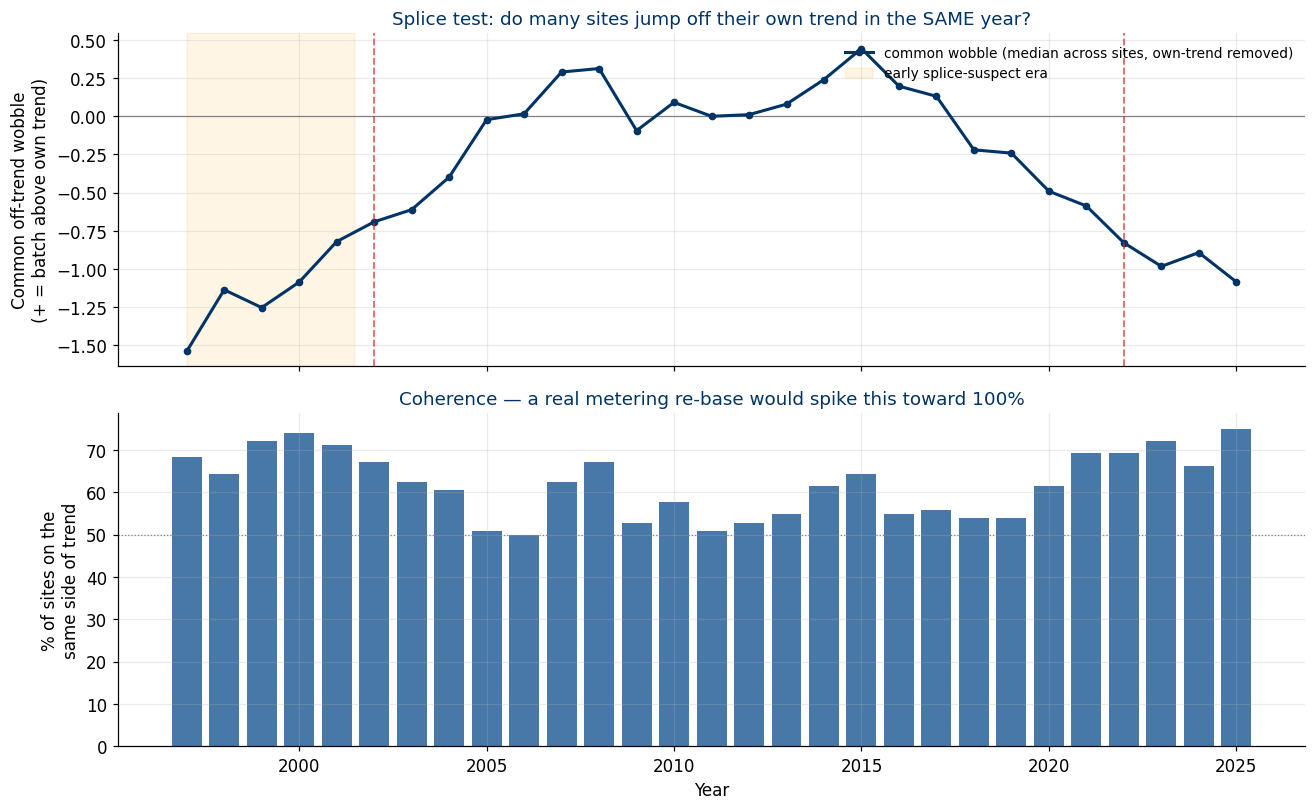


Peak coherence in any year: 75% (year 2025 — the end of the record, where most sites are
simply leading together because the whole grid has gone leading, not a splice).
The common wobble is a smooth wave (trend curvature), not a cliff. [V]


In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True)
ax1.axhline(0, color="grey", lw=0.8)
ax1.plot(years, common.values, "-o", color=repro.EA_BLUE, lw=2, ms=4,
         label="common wobble (median across sites, own-trend removed)")
ax1.axvspan(years[0], 2001.5, color="orange", alpha=0.10, label="early splice-suspect era")
for sy in sync_years:
    ax1.axvline(sy, color=repro.RED, ls="--", lw=1.2, alpha=0.7)
ax1.set_ylabel("Common off-trend wobble\n(+ = batch above own trend)")
ax1.set_title("Splice test: do many sites jump off their own trend in the SAME year?")
ax1.legend(loc="upper right", fontsize=9)
ax2.bar(years, coherence.values * 100, color="#4878a8")
ax2.axhline(50, color="grey", lw=0.8, ls=":")
ax2.set_ylabel("% of sites on the\nsame side of trend"); ax2.set_xlabel("Year")
ax2.set_title("Coherence — a real metering re-base would spike this toward 100%")
fig.tight_layout(); fig.savefig(repro.FIGURES / "01_splice_test.png"); plt.show()

print(f"\nPeak coherence in any year: {coherence.max()*100:.0f}% "
      f"(year {int(coherence.idxmax())} — the end of the record, where most sites are")
print("simply leading together because the whole grid has gone leading, not a splice).")
print("The common wobble is a smooth wave (trend curvature), not a cliff. [V]")

## 4. A second robustness test: does the drift survive removing contaminated sites?

**Plain bottom line.** Section 3 ruled out a *metering* artefact (a splice). This section
rules out a different objection: *"your trend is driven by a few odd sites where the meter
isn't really watching distribution at all."* Notebook 00 built a contamination flag — the six
**decoupled** grid exit points whose reactive power is set by Transpower plant or an embedded
synchronous generator rather than by load (plus the steady-generation and net-export sites for
a stricter cut). Here we simply **throw them out and re-measure.** The honest test of a
headline is whether it survives deleting every site you could show was messy.

**What to watch, and why we change what we lead with.** Two kinds of number behave very
differently under this test, and the difference is the whole point:

- The **absolute** national total (Σ MVAr) and the **MVAr-per-year** slope *shrink* when the
  contaminated sites come out — because a couple of those sites (Islington, Bromley) carry
  large, artificially-leading reactive values. So the absolute *level* is partly inflated by
  contamination. We therefore treat the absolute spine as **contamination-sensitive** and stop
  leading with it.
- The **per-MW drift** (reactive drift per megawatt of load — the *intensity* of the shift,
  independent of which big nodes are in the set) and the **share of networks that have gone
  leading** are essentially **unchanged**. These describe the phenomenon itself, not the size
  of the sites measuring it, so they are the robust quantities. **We lead the paper with
  these.**

**Glossary:** *per-MW drift* — for each GXP we divide its overnight reactive by its overnight
load (MVAr per MW) and fit a trend; the median across sites is the typical *intensity* of the
leading drift, which cannot be inflated by simply having a few large nodes in the sample.

In [9]:
flag = pd.read_csv(repro.CACHE / "contamination_flag.csv")
clean_gxps = set(flag.loc[~flag.decoupled, "gxp"])              # drop the 6 decoupled sites
strict_gxps = set(flag.loc[~flag.contaminated, "gxp"])         # also drop steady-DG / net-export


def per_mw_drift(df):
    """Median per-GXP trend of overnight reactive PER MW of load (intensity, size-independent)."""
    slopes = []
    for _, s in df.groupby("gxp"):
        s = s.sort_values("year")
        if len(s) >= 10:
            slopes.append(np.polyfit(s.year, s.on_Q / s.on_P.clip(lower=0.1), 1)[0])
    return float(np.median(slopes)) if slopes else np.nan


def cohort_row(df):
    g = df.groupby("year").on_Q.sum()
    a, b = df[df.year == y0], df[df.year == y1]
    return dict(n=df.gxp.nunique(),
                q0=a.on_Q.sum(), lead0=(a.on_Q < 0).mean() * 100,
                q1=b.on_Q.sum(), lead1=(b.on_Q < 0).mean() * 100,
                slope=np.polyfit(g.index, g.values, 1)[0],
                permw=per_mw_drift(df))


cohorts = {"FULL (demand panel)": bal,
           "CLEAN (−6 decoupled)": bal[bal.gxp.isin(clean_gxps)],
           "CLEAN-STRICT (−DG/export)": bal[bal.gxp.isin(strict_gxps)]}
summary = {name: cohort_row(df) for name, df in cohorts.items()}

print("Headline trajectory on the balanced demand panel — full vs decontaminated cohorts:")
print(f"{'cohort':28s} {'n':>4s} {'Σon_Q '+str(y0):>11s} {'Σon_Q '+str(y1):>11s} "
      f"{'%lead '+str(y0):>9s} {'%lead '+str(y1):>9s} {'MVAr/yr':>9s} {'per-MW/yr':>10s}")
for name, r in summary.items():
    print(f"{name:28s} {r['n']:4d} {r['q0']:+8.0f}    {r['q1']:+8.0f}    "
          f"{r['lead0']:6.0f}%   {r['lead1']:6.0f}%   {r['slope']:+7.1f}  {r['permw']:+9.4f}")

permw_vals = [summary[n]["permw"] for n in cohorts]
print(f"\nABSOLUTE level (Σon_Q {y1}): {summary['FULL (demand panel)']['q1']:+.0f} -> "
      f"{summary['CLEAN-STRICT (−DG/export)']['q1']:+.0f} MVAr  — shrinks (contamination-sensitive).")
print(f"PER-MW drift: {permw_vals[0]:+.4f} -> {permw_vals[1]:+.4f} -> {permw_vals[2]:+.4f} /yr "
      f"— essentially unchanged (robust; if anything stronger on the clean cohort).")
print(f"% of networks leading by {y1}: {summary['FULL (demand panel)']['lead1']:.0f}% -> "
      f"{summary['CLEAN-STRICT (−DG/export)']['lead1']:.0f}%  — the near-universal migration survives.")

Headline trajectory on the balanced demand panel — full vs decontaminated cohorts:
cohort                          n  Σon_Q 1997  Σon_Q 2025 %lead 1997 %lead 2025   MVAr/yr  per-MW/yr
FULL (demand panel)           123     +466        -451         1%       75%     -31.1    -0.0175
CLEAN (−6 decoupled)          119     +438        -298         1%       74%     -26.2    -0.0178
CLEAN-STRICT (−DG/export)      92     +365        -302         1%       80%     -23.4    -0.0180

ABSOLUTE level (Σon_Q 2025): -451 -> -302 MVAr  — shrinks (contamination-sensitive).
PER-MW drift: -0.0175 -> -0.0178 -> -0.0180 /yr — essentially unchanged (robust; if anything stronger on the clean cohort).
% of networks leading by 2025: 75% -> 80%  — the near-universal migration survives.


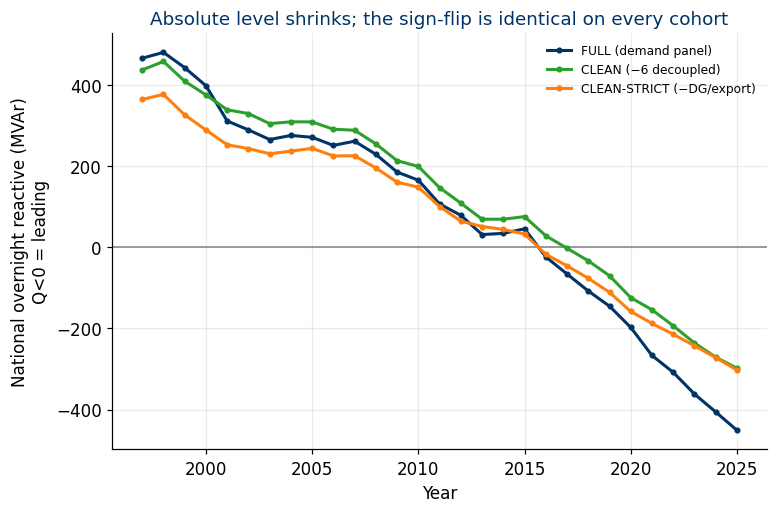

In [10]:
# Publication layout (Aug 2026 figure surgery): single panel at column width — the per-MW
# bars (−0.0175/−0.0178/−0.0180) are a one-sentence result carried in the text/caption.
fig, ax = plt.subplots(figsize=(7.2, 4.8))
ccol = {"FULL (demand panel)": repro.EA_BLUE, "CLEAN (−6 decoupled)": repro.GREEN,
        "CLEAN-STRICT (−DG/export)": repro.ORANGE}
ax.axhline(0, color="grey", lw=1)
for name, df in cohorts.items():
    g = df.groupby("year").on_Q.sum()
    ax.plot(g.index, g.values, "-o", color=ccol[name], lw=2, ms=3, label=name)
ax.set_xlabel("Year")
ax.set_ylabel("National overnight reactive (MVAr)\nQ<0 = leading")
ax.set_title("Absolute level shrinks; the sign-flip is identical on every cohort")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout(); fig.savefig(repro.FIGURES / "01_clean_cohort.png"); plt.show()

**How to read this / what it does NOT mean.** The three curves on the left are near-parallel:
removing the contaminated sites lowers the *height* of the leading total (a few large,
plant-contaminated nodes are gone) but does not change the *shape* — every cohort still crosses
from lagging to leading and lands deep in leading territory. The per-MW drift bars on the right
are the same to within a few percent. So the contamination affected **how big** the leading
total looks, not **whether** the near-universal leading drift is real. This is why, from here
on, the paper leads with the **per-MW drift** and the **share of networks gone leading**, and
reports the absolute MVAr spine (−30.3 MVAr/yr, −296 MVAr) as a real but
**contamination-sensitive** companion — its *level* is partly inflated by a few plant nodes,
its *direction and intensity* are not.

## 5. Five further pre-submission checks (fresh-eyes referee review, Jul 2026)

A hostile-referee pass over the paper draft asked five quantitative questions the sections
above do not answer explicitly. Each has a cheap, decisive answer from the same panel (and,
for the seasonal split, from the raw half-hourly files). The numbers printed here are the
ones quoted in the paper.

1. **The denominator.** The paper leads with a per-MW intensity; if overnight *load* had
   shrunk over the record, the intensity could partly be a shrinking denominator.
2. **Season.** Is the drift a winter (heating-load) phenomenon, or present all year?
3. **The modern-fleet era.** The 2010–13 meter replacement pre-dates the crossing; does the
   drift on 2014–2025 alone (wholly on the modern ION8800A fleet) match the full record?
4. **Slope uncertainty.** The headline −31.1 MVAr/yr is an OLS description; report the
   robust (Theil–Sen) slope and its 95% interval once, so the headline carries error bars.
5. **Survivorship direction.** The balanced panel excludes post-1997 entrants; are the
   excluded demand GXPs *more* or *less* leading than the panel — i.e. which way does the
   remaining churn bias the national picture?

Plus a familiar-units companion: the overnight **aggregate power factor** in 1997 and 2025,
computed the only additive way (ΣP / √(ΣP² + ΣQ²)), never by averaging power factors.

In [11]:
# (1) The denominator: overnight load on the balanced demand panel grew, it did not shrink.
nat_onP = bal.groupby("year").on_P.sum()
onP_slope = np.polyfit(nat_onP.index, nat_onP.values, 1)[0]
print("(1) Overnight load, balanced demand panel:")
print(f"    {y0}: {nat_onP.loc[y0]:,.0f} MW  ->  {y1}: {nat_onP.loc[y1]:,.0f} MW   ({onP_slope:+.0f} MW/yr)")
print("    -> load GREW while Q went leading: the per-MW drift is not a shrinking-denominator artefact.")

# (4) Robust slope with uncertainty for the headline national series.
ts_slope, ts_int, ts_lo, ts_hi = stats.theilslopes(nat_on.values.astype(float),
                                                   nat_on.index.values.astype(float))
print(f"\n(4) Headline overnight trend, balanced demand panel:")
print(f"    Theil–Sen {ts_slope:+.1f} MVAr/yr (95% CI [{ts_lo:+.1f}, {ts_hi:+.1f}]);  OLS {slope_on:+.1f} MVAr/yr")

# (3) Modern-fleet-only check: 2014–2025, wholly after the 2010–13 ION8800A replacement.
mod = bal[bal.year >= 2014]
g14 = mod.groupby("year").on_Q.sum()
mod_slope = np.polyfit(g14.index, g14.values, 1)[0]
permw_full, permw_mod = per_mw_drift(bal), per_mw_drift(mod)
print(f"\n(3) Modern-fleet era (2014–2025, pure ION8800A record):")
print(f"    aggregate slope {mod_slope:+.1f} MVAr/yr;  per-MW drift {permw_mod:+.4f} vs full-record {permw_full:+.4f} MVAr/MW/yr")
print("    -> the drift measured wholly within the modern fleet is at least as steep as the full record;")
print("       the 2010–13 upgrade cannot be manufacturing it.")

# (PF) The familiar-units companion, aggregate overnight power factor.
print("\n(PF) Overnight aggregate power factor (ΣP/√(ΣP²+ΣQ²)), balanced demand panel:")
for yr in (y0, y1):
    Pyr, Qyr = bal.loc[bal.year == yr, "on_P"].sum(), bal.loc[bal.year == yr, "on_Q"].sum()
    pf = abs(Pyr) / np.hypot(Pyr, Qyr)
    print(f"    {yr}: PF = {pf:.3f} {'lagging' if Qyr > 0 else 'leading'}   (ΣP {Pyr:,.0f} MW, ΣQ {Qyr:+,.0f} MVAr)")

# (5) Survivorship: are the demand GXPs EXCLUDED from the balanced panel more or less leading?
snap = panel[(panel.year == y1) & (panel.on_P >= 1.0)].copy()
snap["qpm"] = snap.on_Q / snap.on_P
b_med = snap.loc[snap.balanced, "qpm"].median()
nb_med = snap.loc[~snap.balanced, "qpm"].median()
permw_nonbal = per_mw_drift(panel[~panel.balanced])
print(f"\n(5) Survivorship direction ({y1} snapshot, demand GXPs with ≥1 MW overnight load):")
print(f"    median overnight Q per MW: balanced panel ({snap.balanced.sum()} GXPs) {b_med:+.3f}; "
      f"excluded entrants/exits ({(~snap.balanced).sum()} GXPs) {nb_med:+.3f} MVAr/MW")
print(f"    per-MW drift of non-balanced demand GXPs (≥10 yrs of data): {permw_nonbal:+.4f} vs balanced {permw_full:+.4f}")
print("    -> if the excluded sites are the more-leading set, the balanced panel UNDERSTATES the national")
print("       drift, i.e. residual churn bias is conservative. (Read the sign from the numbers above.)")

# These four numbers are quoted in the paper's Section II-B churn-bias sentence; this cell
# is their canonical recipe (2025 snapshot at >=1 MW overnight load for the medians; the
# >=10-year per-MW drift rule for the slopes; demand networks throughout).
assert nb_med < b_med and permw_nonbal < permw_full, \
    "churn-bias direction: excluded demand GXPs must be MORE leading and faster-drifting than the panel"
assert abs(nb_med + 0.28) < 0.005 and abs(b_med + 0.18) < 0.005, \
    f"II-B churn medians drifted from print (excluded {nb_med:+.3f} vs panel {b_med:+.3f}; paper -0.28/-0.18)"
assert abs(permw_nonbal + 0.020) < 0.0005 and abs(permw_full + 0.018) < 0.0005, \
    f"II-B churn drifts drifted from print ({permw_nonbal:+.4f} vs {permw_full:+.4f}; paper -0.020/-0.018)"

(1) Overnight load, balanced demand panel:
    1997: 1,682 MW  ->  2025: 1,963 MW   (+9 MW/yr)
    -> load GREW while Q went leading: the per-MW drift is not a shrinking-denominator artefact.

(4) Headline overnight trend, balanced demand panel:
    Theil–Sen -31.3 MVAr/yr (95% CI [-34.0, -28.1]);  OLS -31.1 MVAr/yr

(3) Modern-fleet era (2014–2025, pure ION8800A record):
    aggregate slope -47.3 MVAr/yr;  per-MW drift -0.0193 vs full-record -0.0175 MVAr/MW/yr
    -> the drift measured wholly within the modern fleet is at least as steep as the full record;
       the 2010–13 upgrade cannot be manufacturing it.

(PF) Overnight aggregate power factor (ΣP/√(ΣP²+ΣQ²)), balanced demand panel:
    1997: PF = 0.964 lagging   (ΣP 1,682 MW, ΣQ +466 MVAr)
    2025: PF = 0.975 leading   (ΣP 1,963 MW, ΣQ -451 MVAr)

(5) Survivorship direction (2025 snapshot, demand GXPs with ≥1 MW overnight load):
    median overnight Q per MW: balanced panel (103 GXPs) -0.185; excluded entrants/exits (29 GXPs) -

### (2) The seasonal split — winter vs summer, from the raw half-hourly record

The overnight window (TP 6–10) is averaged over the whole year above. If the drift were a
**winter-only** phenomenon it could reflect heating-load composition rather than a
year-round fleet change. Here we recompute the national overnight aggregate separately for
**winter (Jun–Aug)** and **summer (Dec–Feb)** months, on the same balanced demand panel,
directly from the 29 years of half-hourly files.

In [12]:
bal_gxps = set(bal.gxp.unique())
WINTER, SUMMER = {6, 7, 8}, {12, 1, 2}
seas_rows = []
for f in sorted(repro.processed_dir().glob("*_power_factor_gxps.parquet")):
    dfy = pd.read_parquet(f)
    date_level = [n for n in dfy.index.names if n and "Period" not in n][0]
    dates = pd.to_datetime(dfy.index.get_level_values(date_level))
    tp = dfy.index.get_level_values("Trading_Period").to_numpy()
    on = np.isin(tp, list(range(6, 11)))
    Qw = dfy.xs("Q", axis=1, level=0)
    Pw = dfy.xs("P", axis=1, level=0)
    keep = [c for c in Qw.columns if c[1] in bal_gxps]
    Qw, Pw = Qw[keep], Pw[keep]
    months = dates.month.to_numpy()
    for name, mset in (("winter", WINTER), ("summer", SUMMER)):
        sel = on & np.isin(months, list(mset))
        seas_rows.append(dict(year=int(f.name[:4]), season=name,
                              Q=Qw[sel].mean().sum(), P=Pw[sel].mean().sum()))
seas = pd.DataFrame(seas_rows)

print("(2) Seasonal overnight aggregates, balanced demand panel:")
for name in ("winter", "summer"):
    s = seas[seas.season == name].sort_values("year")
    sl = np.polyfit(s.year, s.Q, 1)[0]
    neg = s.loc[s.Q < 0, "year"]
    cross = int(neg.min()) if len(neg) else None
    print(f"    {name:6s}: {s.Q.iloc[0]:+.0f} MVAr ({s.year.iloc[0]}) -> {s.Q.iloc[-1]:+.0f} MVAr ({s.year.iloc[-1]}); "
          f"slope {sl:+.1f} MVAr/yr; crosses net-leading {cross}")
print("    -> the lagging-to-leading drift is present in BOTH seasons; it is not a winter"
      " (heating-composition) artefact.")

(2) Seasonal overnight aggregates, balanced demand panel:
    winter: +439 MVAr (1997) -> -495 MVAr (2025); slope -31.1 MVAr/yr; crosses net-leading 2013
    summer: +523 MVAr (1997) -> -443 MVAr (2025); slope -30.8 MVAr/yr; crosses net-leading 2017
    -> the lagging-to-leading drift is present in BOTH seasons; it is not a winter (heating-composition) artefact.


## Verdict for notebook 01

- **The trajectory is real.** Overnight national reactive power drifted from strongly
  lagging to clearly leading over 29 years, crossing zero around 2019–2020. On the balanced
  demand panel the absolute spine is −31.1 MVAr/yr (−30.3 across all balanced GXPs); the
  robust, contamination-proof statement of the same shift is a **per-MW drift of ≈ −0.018
  MVAr/MW/yr** and a migration from ~1% to ~75% of networks net-leading overnight. The
  evening peak did not follow — this is an overnight, low-load phenomenon. **[V]**
- **It is not a metering artefact.** The trend survives dropping the early splice-suspect
  years; a naive detector's "steps" are curvature it is forced to invent; and the decisive
  synchronous-batch test, while it marks candidate years (≈2002, ≈2022), finds **no
  coherence spike** at them — they are curve-bends, not coordinated metering re-bases. **[V]**
- **It is not driven by a few contaminated sites.** Removing every decoupled GXP (and, more
  strictly, every steady-DG / net-export GXP) leaves the per-MW drift and the share-leading
  migration essentially unchanged; only the absolute level shrinks, because a couple of large
  plant-contaminated nodes are gone. The headline rests on the robust quantities. **[V]**

**Why this matters for the paper.** Section III can state the 29-year drift as a *measured*
fact, not a conjecture, can pre-empt the "your metering changed" objection in print, and can
lead with a contamination-robust intensity rather than a level that a hostile reviewer could
attribute to a handful of nodes. The next two notebooks ask the harder question: *what is
driving it* — cables, or the changing make-up of electricity demand itself?